In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import seaborn_image as isns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scienceplots
# plt.style.use('science')
sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")

In [2]:
def preprocess_plot(df, name, plotting = True):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        # _, p = stats.ttest_ind(df[(df['Behaviour_6hFD'] == 'Pre')][column].dropna(),
        #                             df[df['Behaviour_6hFD'] == 'Post'][column].dropna(),
        #                             equal_var = True)
        else:
            param_df = df
        
        try:
            _, p = stats.mannwhitneyu(param_df[(param_df.Behaviour_6hFD == 'Pre')][column].dropna(),
                                        param_df[(param_df.Behaviour_6hFD == 'Post')][column].dropna())
            
            print(column , p)

        except ValueError:
            continue

        if plotting:
            try:
                
                fig,ax = plt.subplots(figsize = (2,3))
            
                sns.swarmplot(x='Behaviour_6hFD', y =column, data= param_df, palette = ['darkgray', '#F97306'], alpha = 1)
                sns.boxplot(x='Behaviour_6hFD', y =column, data= param_df, palette = ['darkgray', '#F97306'], boxprops=dict(alpha=0.7), width = 0.5)
                sns.despine()
                plt.title(column + '_' + str(p), pad = 20)
                plt.savefig(f'output_figures/{name}_{column}.png',dpi = 300, bbox_inches = 'tight')
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# epnys analysis

In [9]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
df.loc[df.Behaviour_6hFD =='Agg+','Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)


gal = df[df.Gal_positive == 'yes']
no_gal = df[df.Gal_positive == 'no']
ephys = df[df.Gal_positive.isin(['Unknown', 'no'])]
ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[df.Behaviour_6hFD == 'Post']])
sample_num= int(no_gal.shape[0]/4)
ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 859)]).reset_index(drop = True)


ephys.to_csv('sampled_ephys_data.csv')

## all properties

Cm(pF) 0.2899176420064722


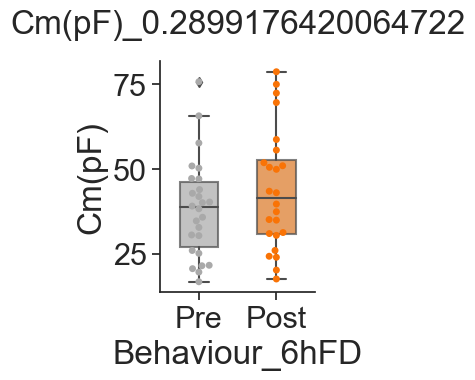

Firing_freq_(Hz)_I0 0.0339234199693772


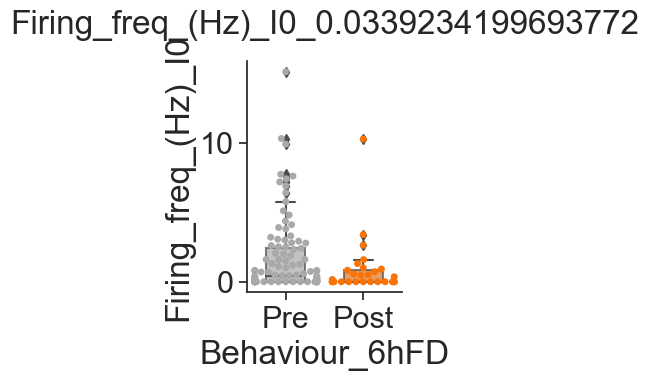

Instant_freq_(Hz) 0.02210822530202638


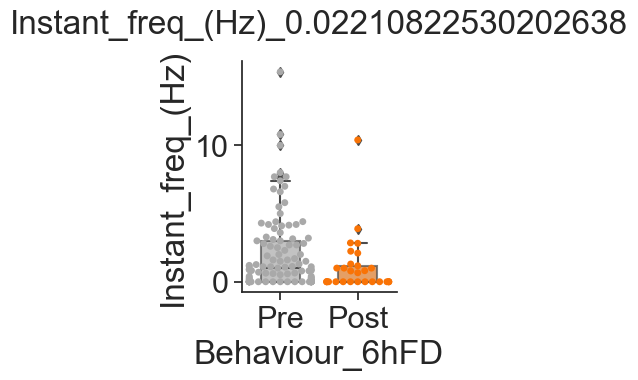

isi_(ms) 0.798374894570286


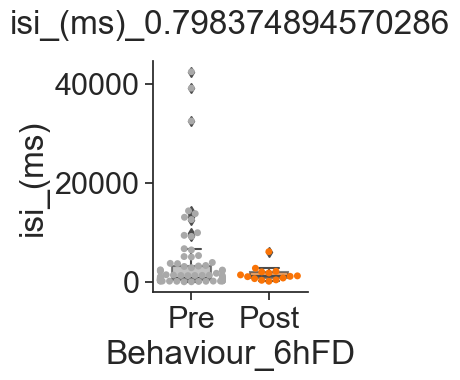

CaT 0.18668975663863507


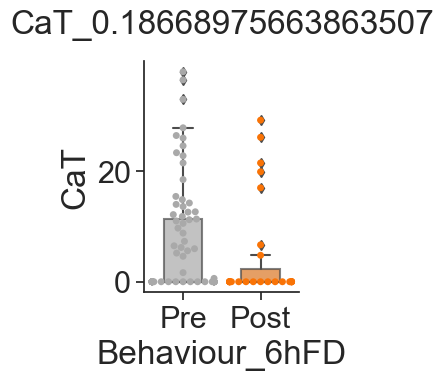

Ih_at_-120mV 0.01015785407464264


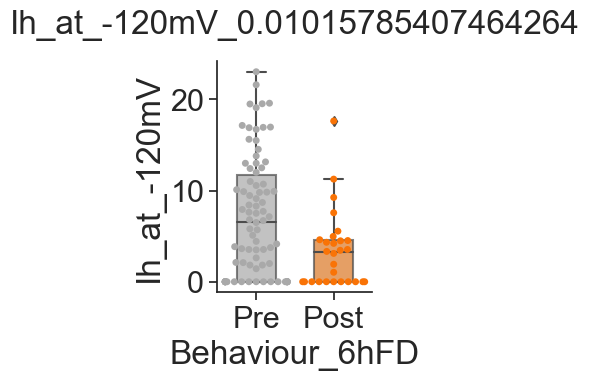

AP_ampl 0.5926995422350196


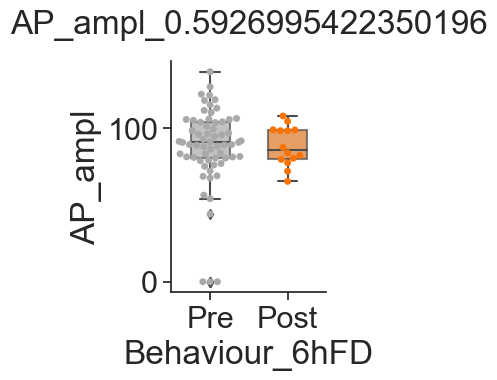

AP_halfwidth 0.4213193053110087


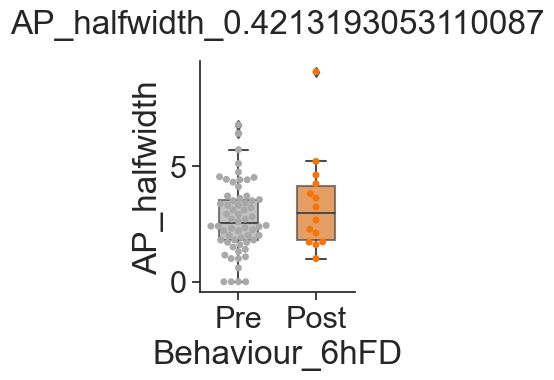

AP_time_to_peak 0.3903991575423652


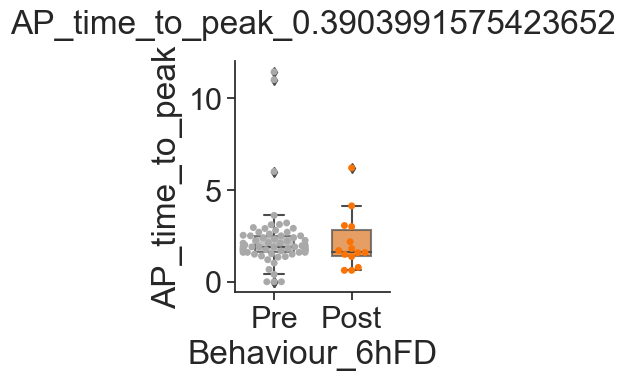

area(mV_ms) 0.8636727431378165


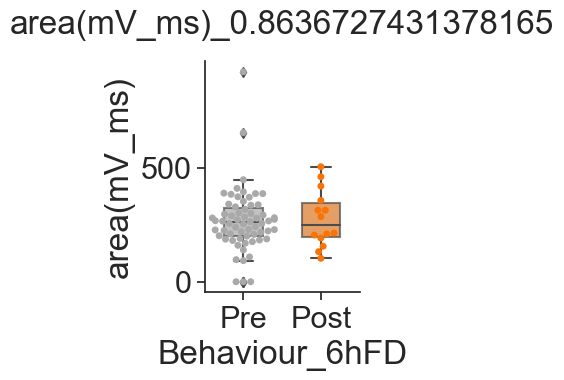

rheobase_at_-60mV_(pA) 0.22029177348493623


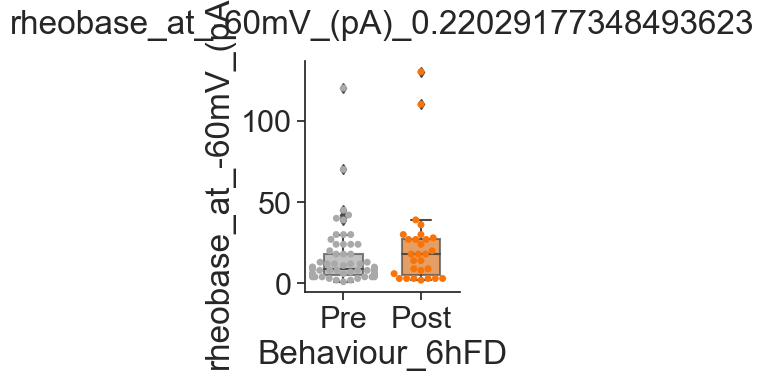

AHP_(mV) 0.6631812498134189


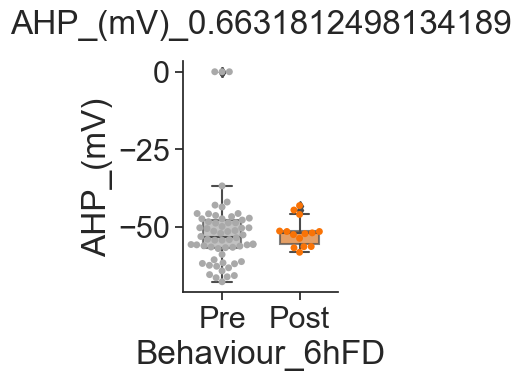

Vm 0.8253358269732731


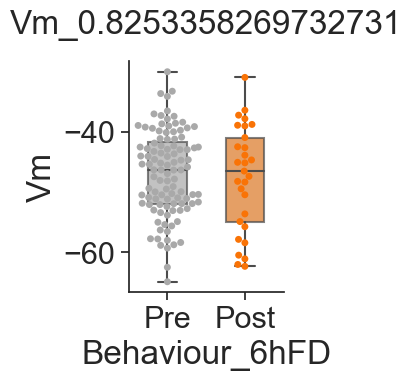

Input_Resistance 0.0012148222921327377


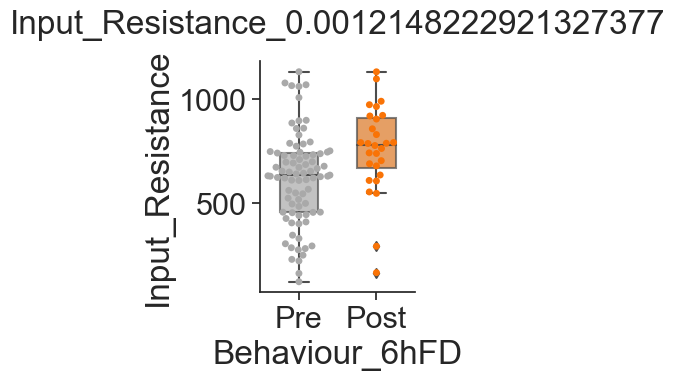

sPSC_frequency 0.9547516307809233


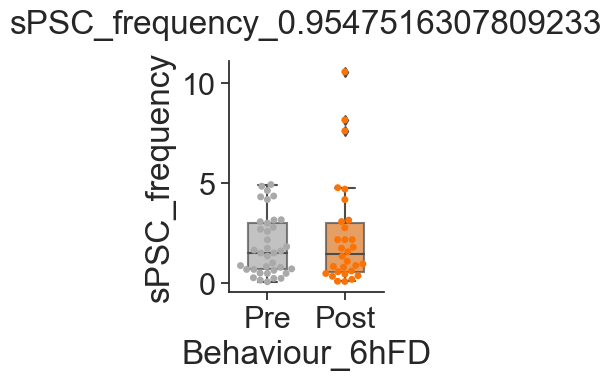

sPSC_Amplitude(pA) 0.7718050765136965


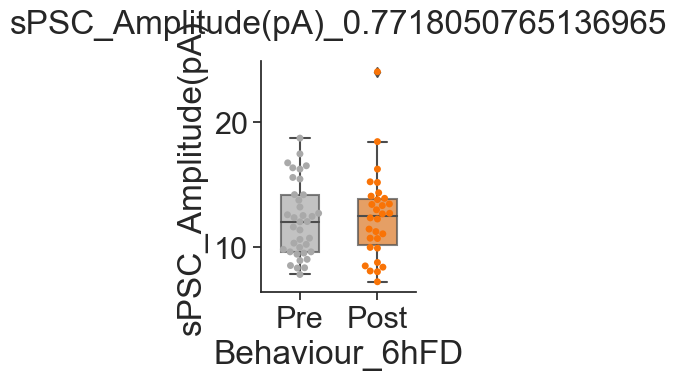

sPSCs_Rise time 0.24066578445307585


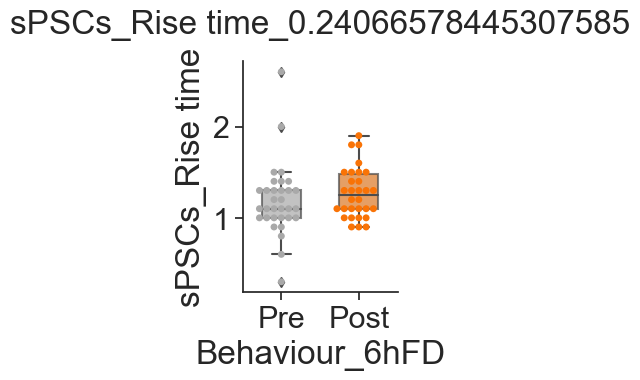

sPSCs (decay) 0.8286719760359287


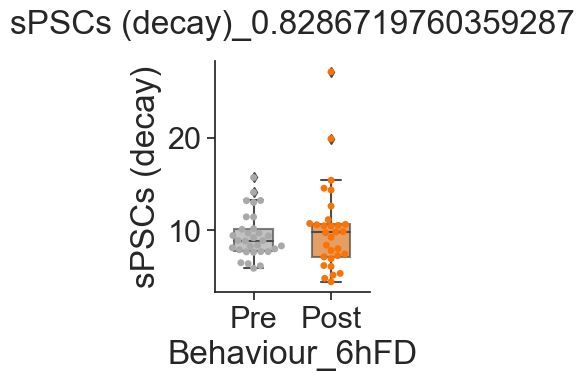

In [10]:
preprocess_plot(ephys, 'pan')


Cm(pF) 0.568000349055369


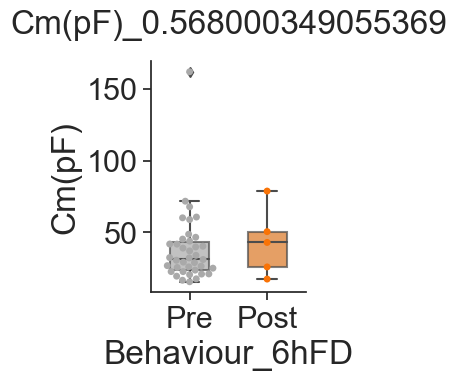

Firing_freq_(Hz)_I0 0.28721546260366726


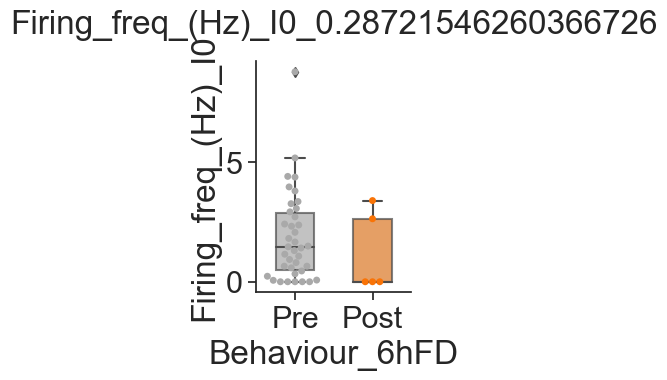

Instant_freq_(Hz) 0.2541927698038654


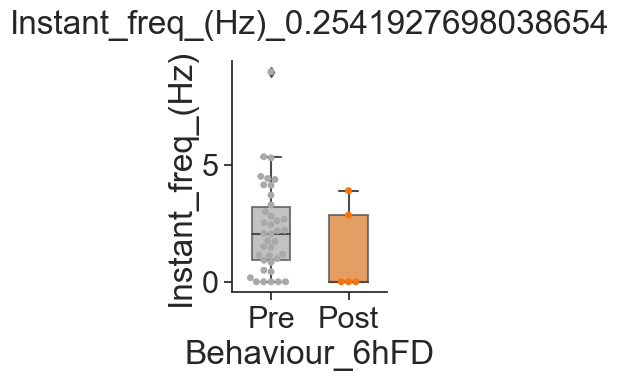

isi_(ms) 0.3025210084033614


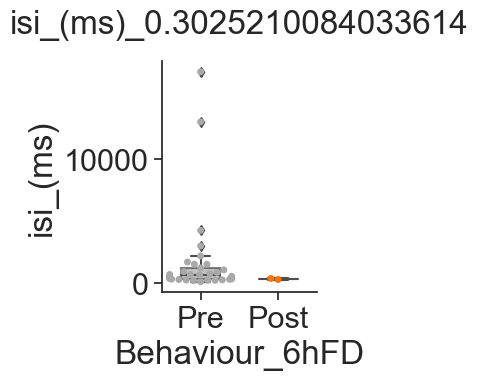

CaT 0.09172696328617409


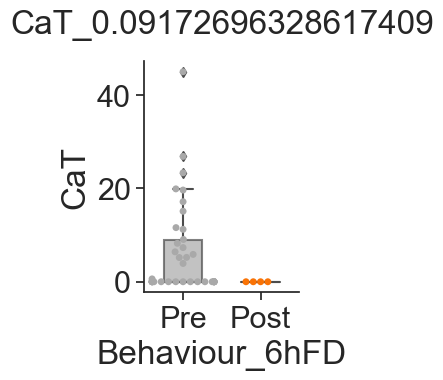

Ih_at_-120mV 0.34655777807143007


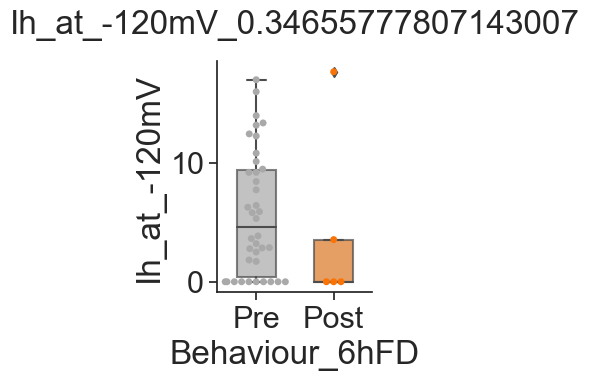

AP_ampl 0.27062944050876925


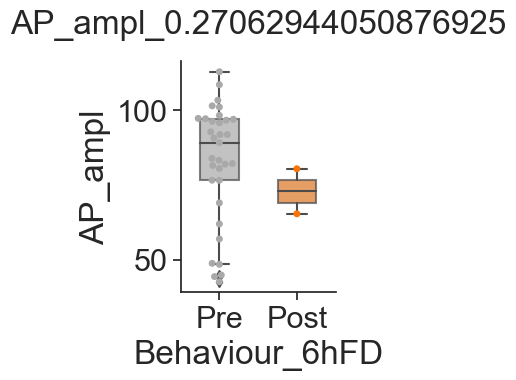

AP_halfwidth 0.7563025210084033


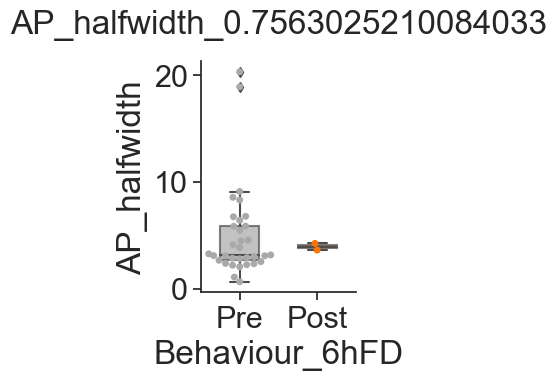

AP_time_to_peak 0.1411764705882353


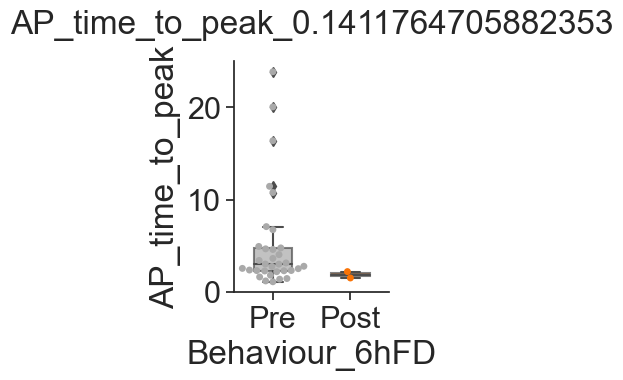

area(mV_ms) 0.3697478991596639


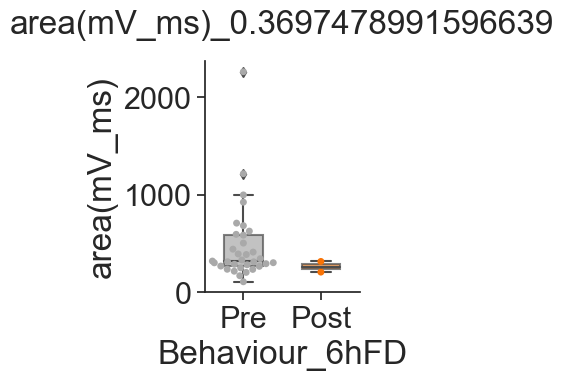

rheobase_at_-60mV_(pA) 0.12860985215882415


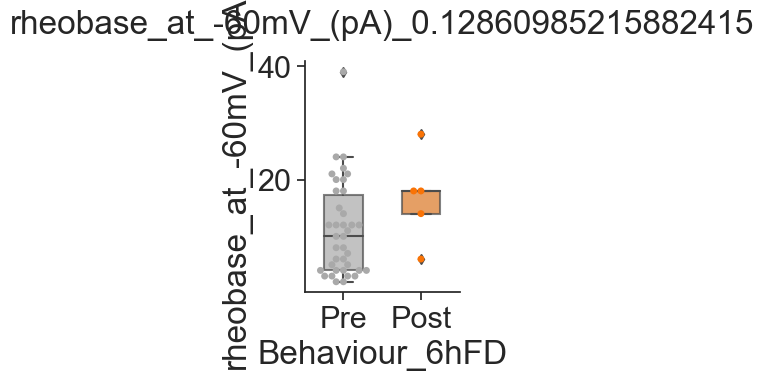

AHP_(mV) 0.27226890756302524


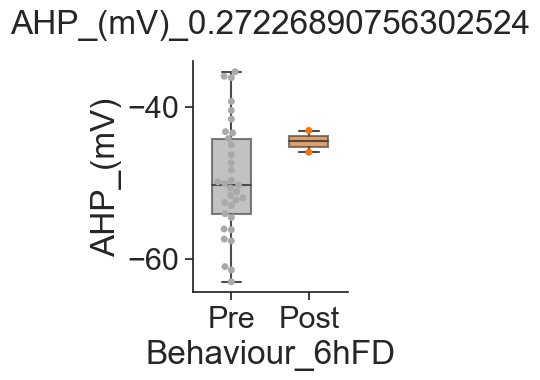

Vm 0.568000349055369


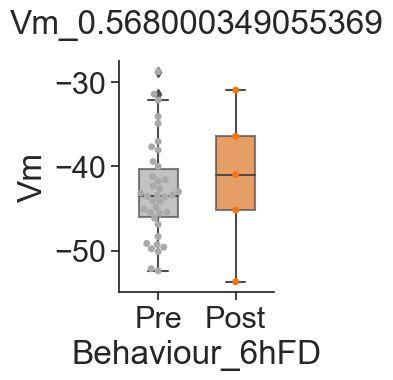

Input_Resistance 0.9560979765177156


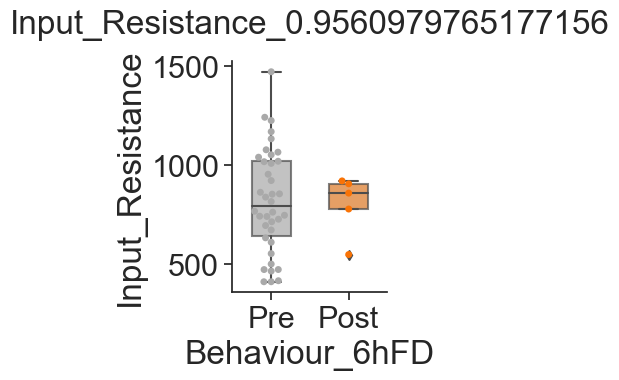

sPSC_frequency 0.07868653086044392


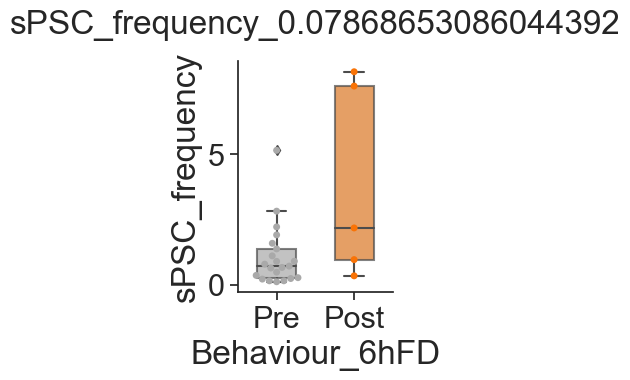

sPSC_Amplitude(pA) 0.8010337488598358


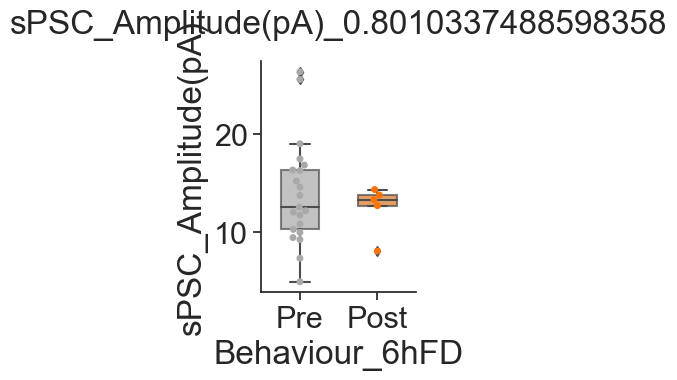

In [29]:
preprocess_plot(gal,'gal')

Cm(pF) 0.4755222982978341


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


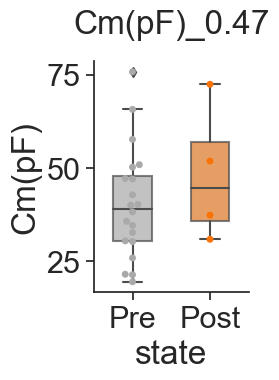

Firing_freq_(Hz)_I0 0.581060812636524


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


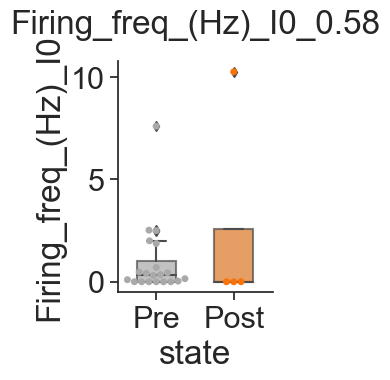

Instant_freq_(Hz) 0.6499865750982734


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


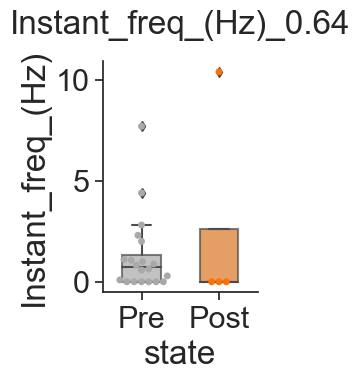

isi_(ms) 0.06426085768202283


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


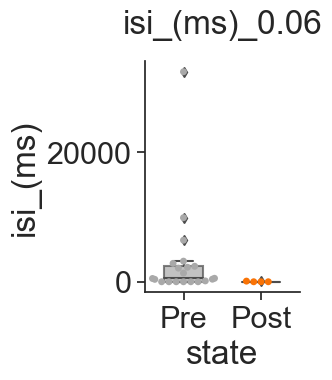

CaT 0.48113205173542367


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


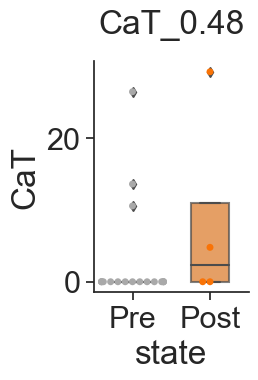

Ih_at_-120mV 0.277449346125114


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


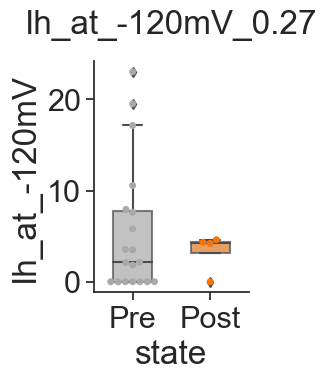

AP_ampl 0.2181514569462177


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


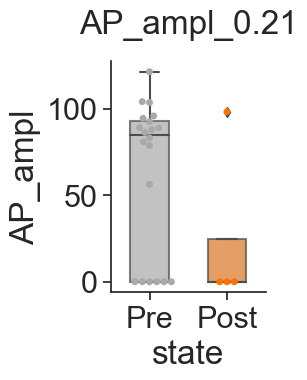

AP_halfwidth 0.009886219132297919


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


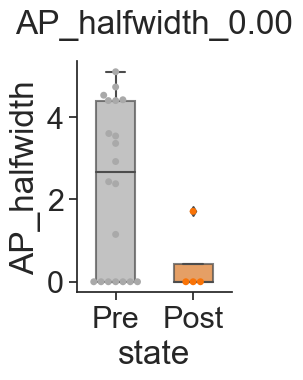

AP_time_to_peak 0.0015549832473598733


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


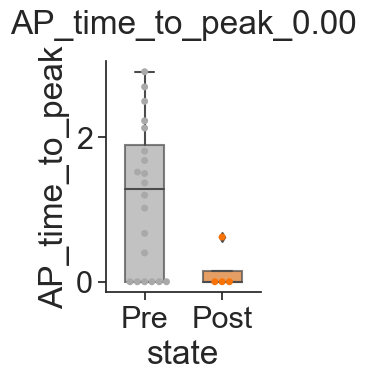

area(mV_ms) 0.00624299937149407


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


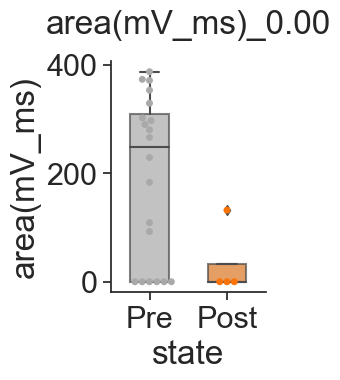

rheobase_at_-60mV_(pA) 0.4696188577698096


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


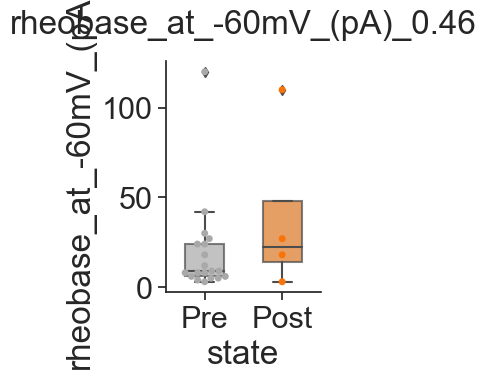

AHP_(mV) 0.1650107567942357


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


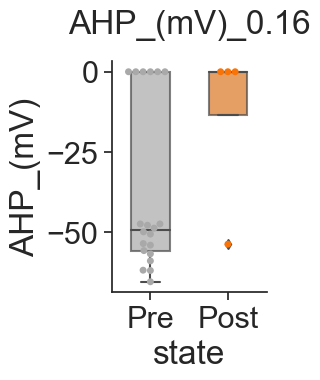

Vm 0.06708229427242103


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


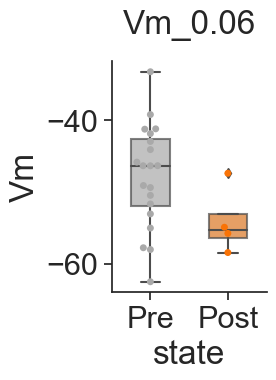

Input_Resistance 0.7693812360276703


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


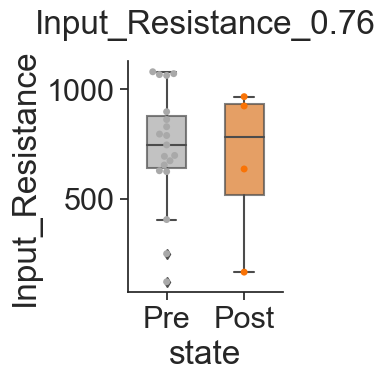

sPSC_frequency 0.5187436831213064


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


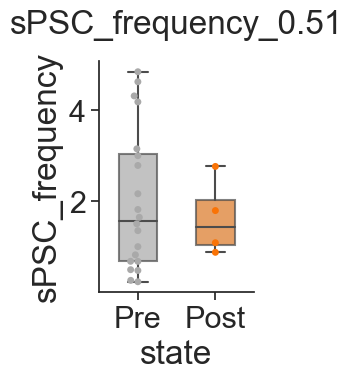

sPSC_Amplitude(pA) 0.7183449380790222


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


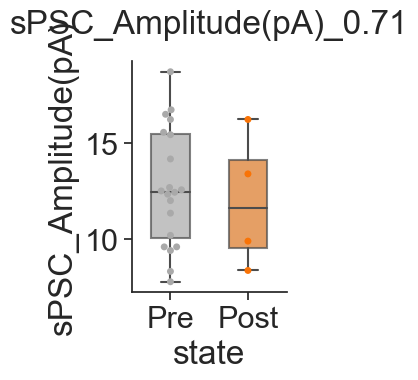

sPSCs_Rise time 0.8300446898829569


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


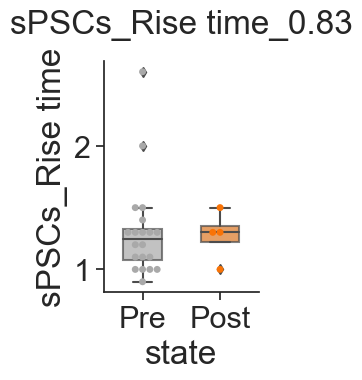

sPSCs (decay) 0.9248707902971536


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


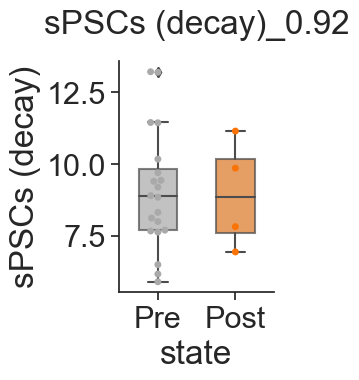

AC-I0 nan


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_86043/1272909905.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='state', y =column, data= df, palette = ['darkgray', '#F97306'], alpha = 1)


KeyError: 'y'

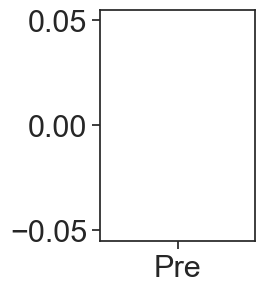

In [7]:
preprocess_plot(no_gal,'gal_minus')

Cm(pF) 0.7323693239926063


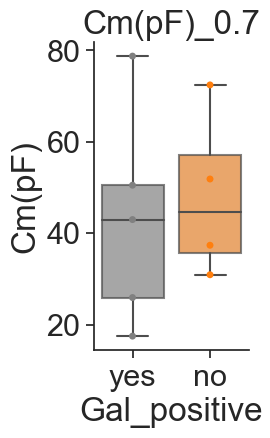

Firing_freq_(Hz)_I0 0.6407646405225094


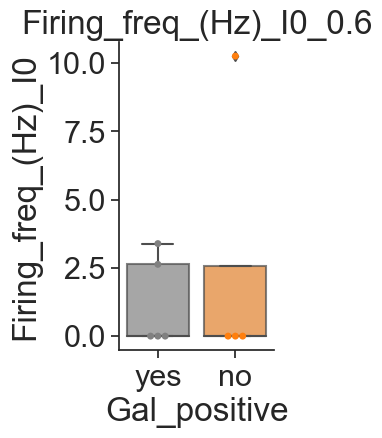

Instant_freq_(Hz) 0.6729139443059836


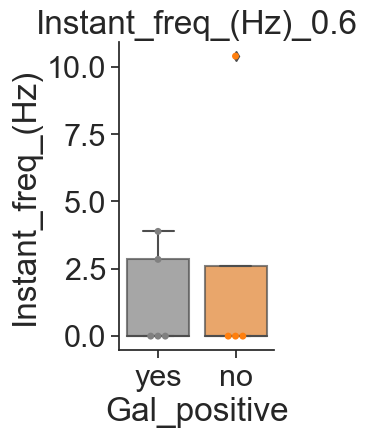

isi_(ms) 0.264690461240659


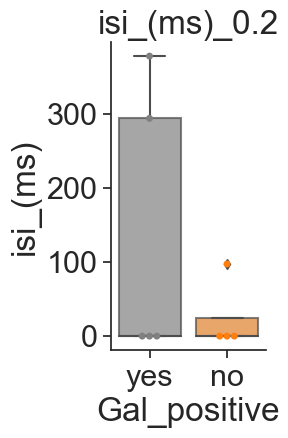

CaT 0.31129113670632236


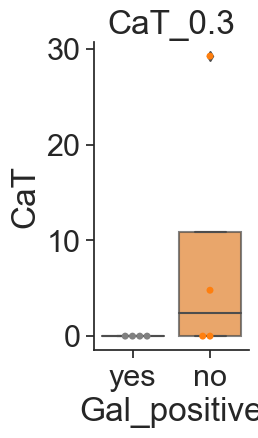

Ih_at_-120mV 0.8027274535869497


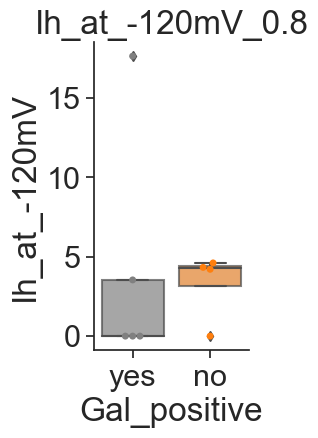

AP_ampl 0.8859255231987084


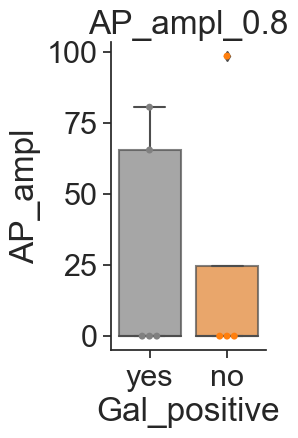

AP_halfwidth 0.32548590700011526


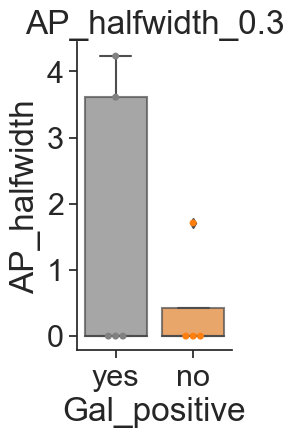

AP_time_to_peak 0.2899382771639767


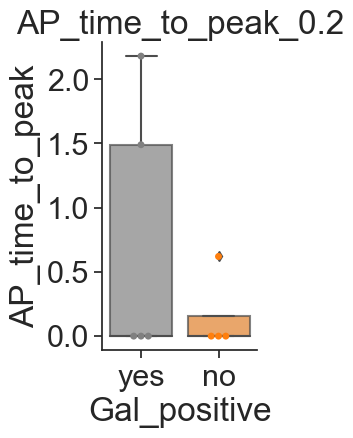

area(mV_ms) 0.37498685458791303


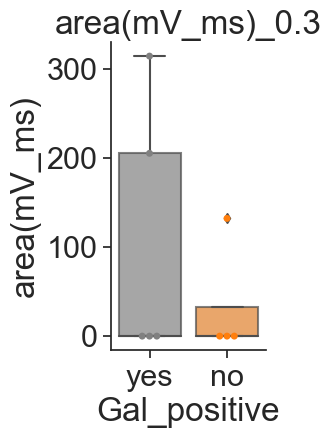

rheobase_at_-60mV_(pA) 0.4161053280322605


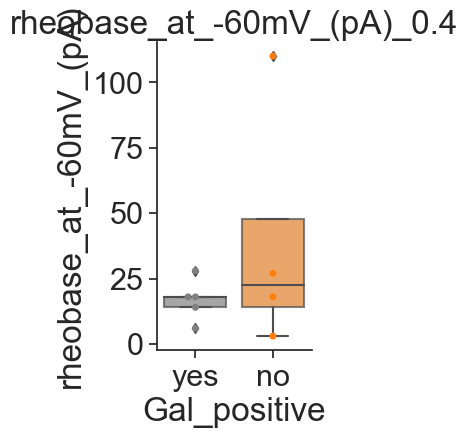

AHP_(mV) 0.80731274924489


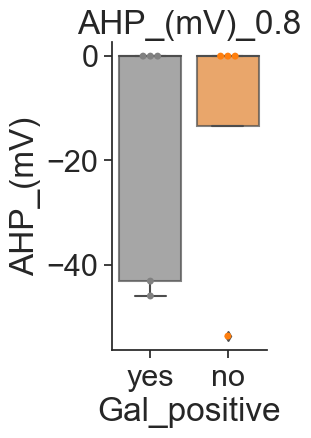

Vm 0.02901537930290683


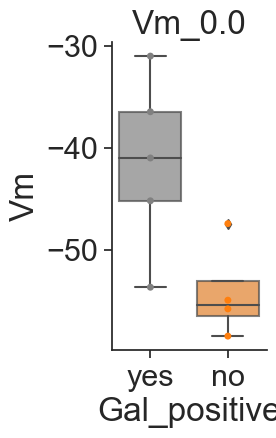

Input_Resistance 0.5478892229399516


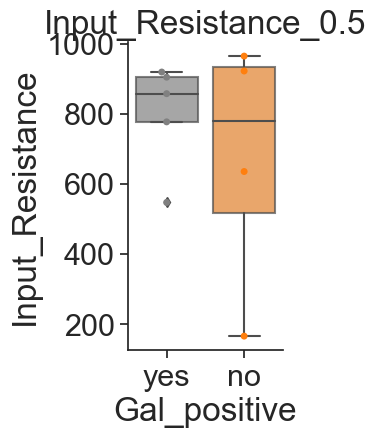

sPSC_frequency 0.2622481192712615


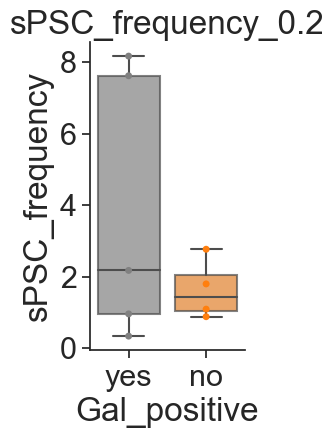

sPSC_Amplitude(pA) 0.8336416545013177


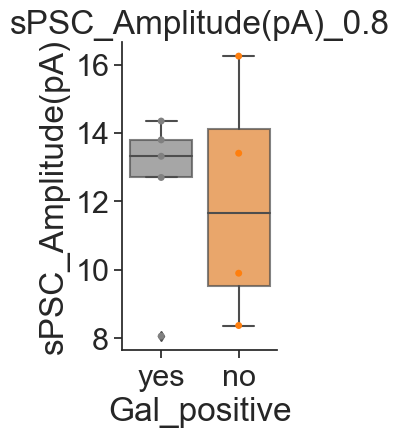

sPSCs_Rise time 0.1506195618276334


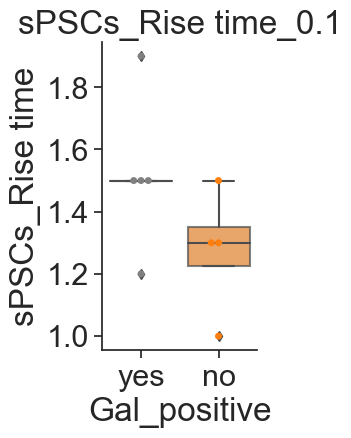

sPSCs (decay) 0.1946103198988769


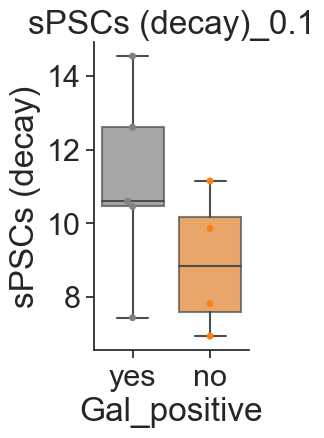

AC-I0 nan


KeyError: 'y'

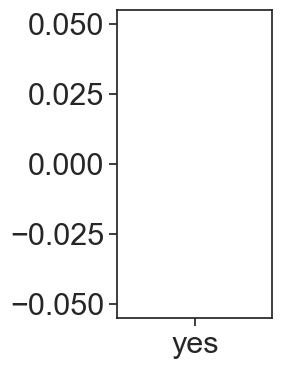

In [12]:
gals = pd.concat([gal,no_gal], axis = 0)
gals = gals[gals.state == 'Post']

ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
   'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    _, p = stats.ttest_ind(gals[(gals.Gal_positive == 'yes')][column].dropna(),
                                gals[(gals.Gal_positive == 'no')][column].dropna(),
                                equal_var = False)
    print(column , p)


    gals[column] = pd.to_numeric(gals[column])
    fig,ax = plt.subplots(figsize = (2,4))
    sns.swarmplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'])
    sns.boxplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
    sns.despine()
    plt.title(column + '_' + str(p)[:3])
    plt.savefig(f'output_figures/gal_nogal_{column}.png',dpi = 300, bbox_inches = 'tight')
    plt.show()

In [10]:
ephys.columns

Index(['experiment_day', 'projection_site', 'sex', 'Gal_positive', 'state',
       'estrous_stage', 'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm(pF)',
       'Adaptive', 'I_zero', 'I_zero_reclassified', '60mV',
       'Firing_freq_(Hz)_I0', 'Instant_freq_(Hz)', 'isi_(ms)', 'cat_categ',
       'CaT', 'Ih', 'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth',
       'AP_time_to_peak', 'area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)',
       'Vm', 'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)',
       'sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60', 'Comments'],
      dtype='object')

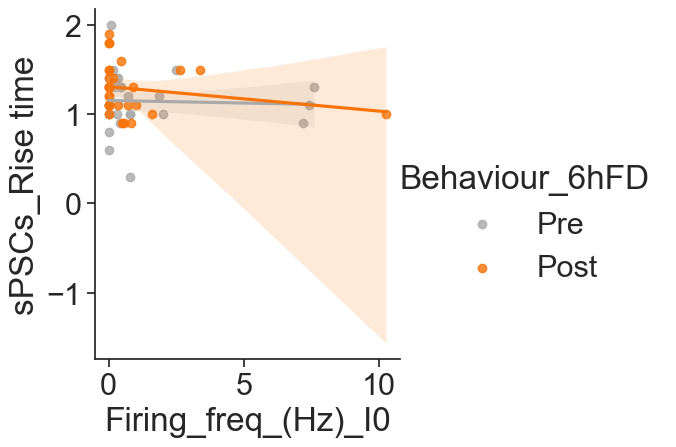

In [11]:
sns.lmplot(x = 'Firing_freq_(Hz)_I0', y = 'sPSCs_Rise time', data = ephys, hue = 'Behaviour_6hFD', palette = ['darkgray', '#F97306'])
          


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


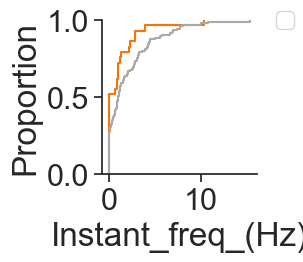

In [12]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306']

fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys, x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

## silent prop

I_zero          phasic  phasic   silent  silent   tonic  tonic   All
Behaviour_6hFD                                                      
Post                 4        2      15        0      8       0   29
Pre                 15        3      26        2     56       3  105
All                 19        5      41        2     64       3  134
0.052753517613170674


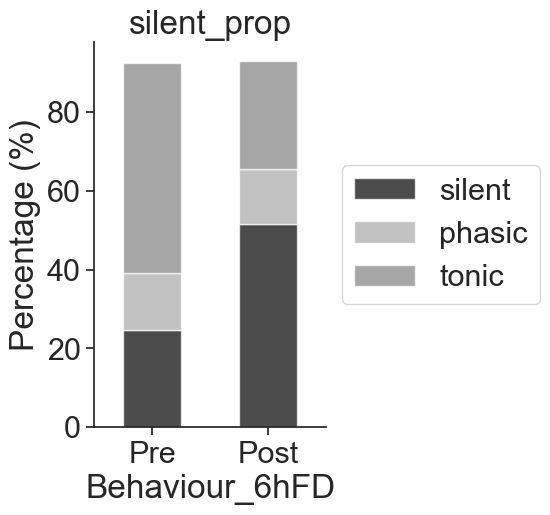

In [13]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
silent_prop = proportion(ephys, 'Behaviour_6hFD', 'I_zero', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], ['Pre', 'Post'])
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [63]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## adaptive prop

Adaptive        ?  no  no   yes  All
Behaviour_6hFD                      
Post            1  12    0   16   29
Pre             1  16    1   26   44
All             2  28    1   42   73
0.8233640745669534


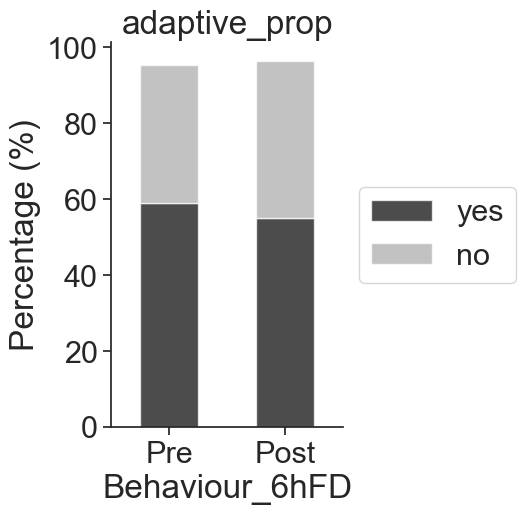

In [14]:
## adaptive proportion
cols = ['yes', 'no']
ad_prop = proportion(ephys, 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], ['Pre', 'Post'])
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ad_prop, 'Behaviour_6hFD')
plt.title('adaptive_prop')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

In [64]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## calcium T prop

cat_categ       no  yes  All
Behaviour_6hFD              
Post            20    8   28
Pre             46   36   82
All             66   44  110
0.22768768851507704


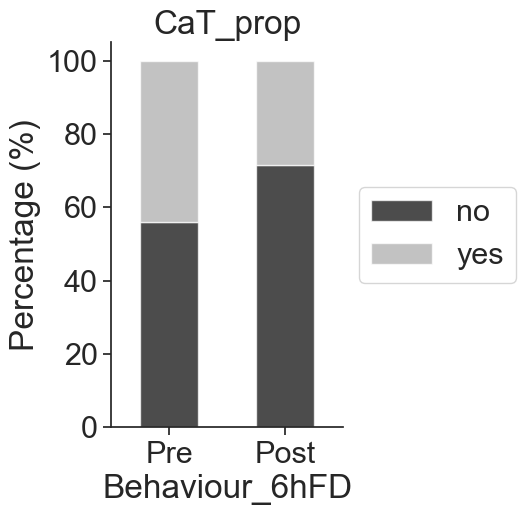

In [15]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], ['Pre', 'Post'])
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

In [66]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

cat_categ       no  yes  All
Behaviour_6hFD              
Pre             15    7   22
Post            13    2   15
0.3700053320928527


Text(0, 0.5, 'percentage of neurons with Calium T')

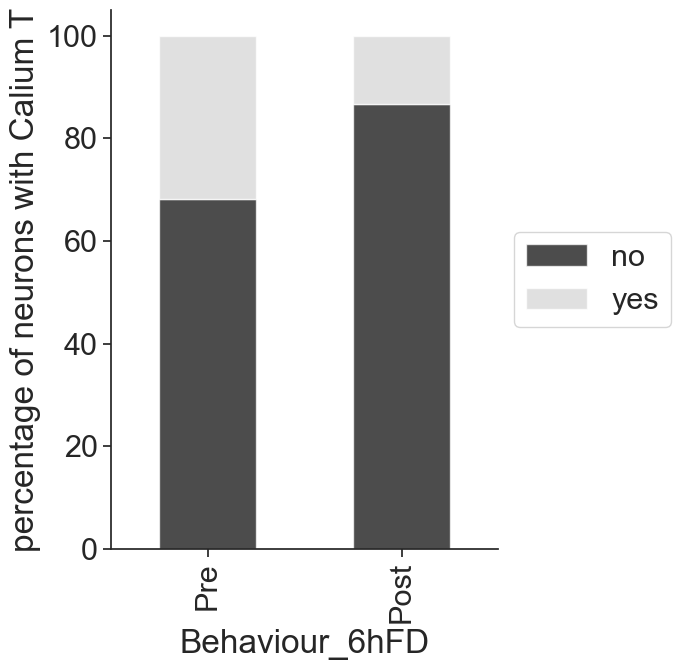

In [16]:
## prop of silent cells with/ without DB
DB_df = ephys[ephys.I_zero == 'silent']
DB_prop = pd.crosstab(DB_df['Behaviour_6hFD'], DB_df['cat_categ'], margins = True).reset_index()
cols = ['Behaviour_6hFD', 'no', 'yes','All']
DB_prop = DB_prop[cols]
DB_prop['Behaviour_6hFD'] = pd.Categorical(DB_prop['Behaviour_6hFD'], ['Pre', 'Post'])
DB_prop = DB_prop.sort_values(by = ['Behaviour_6hFD']).dropna()

plot_df = DB_prop.copy()

## chi square test
DB_prop.index = DB_prop.Behaviour_6hFD
DB_prop.drop(columns = ['Behaviour_6hFD'], inplace = True)
c, p, dof, expected = stats.chi2_contingency(DB_prop.iloc[:,:-1]) 
print(DB_prop)
print(p)

## plotting
plot_df.iloc[:, 1:5] = plot_df.iloc[:, 1:5].div(plot_df.All, axis = 0) *100
plot_df = plot_df.iloc[:, :-1]
plot_df.plot(
          x = 'Behaviour_6hFD', 
          kind = 'bar', 
          stacked = True,  
          mark_right = False,
          color = ['black','lightgray'],
          figsize = (5,7), alpha = 0.7)

ax = plt.gca()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('percentage of neurons with Calium T')

## IH prop

IH              no  yes  All
Behaviour_6hFD              
Post            11   17   28
Pre             22   60   82
All             33   77  110
0.31583956121619616


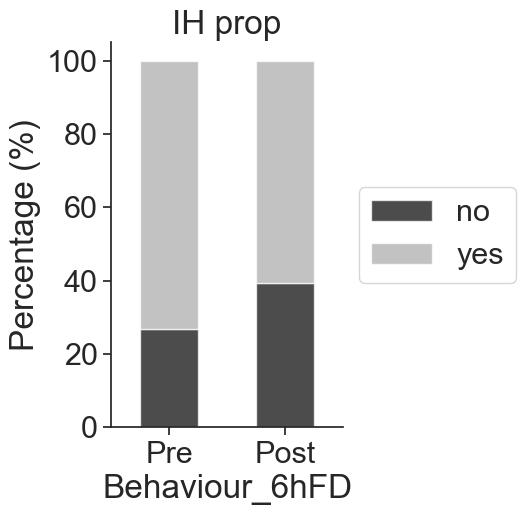

In [17]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], ['Pre', 'Post'])
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

# ramp analysis

In [33]:
df = pd.read_csv('ramps_all.csv')
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)', 
                        'experiment_day':'filename'}, inplace =True)

df.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
df = pd.merge(df, ephys, on = 'filename')

df['Injected'] = pd.Categorical(df['Injected'], df['Injected'].unique()[:-2]).as_ordered()

start = df['Ramp_start'][0]
num_spike = df.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')
df = df.groupby(['filename', 'Injected'], dropna = False)['Behaviour_6hFD', "Event start "].first().reset_index().drop_duplicates()
df.loc[df['Event start '] == 0,'Event start '] = 2080
df['latency'] = df['Event start ']- start
df['num_spike'] = num_spike.num_spike
df =  pd.merge(df, ephys, on = ['filename', 'Behaviour_6hFD'])



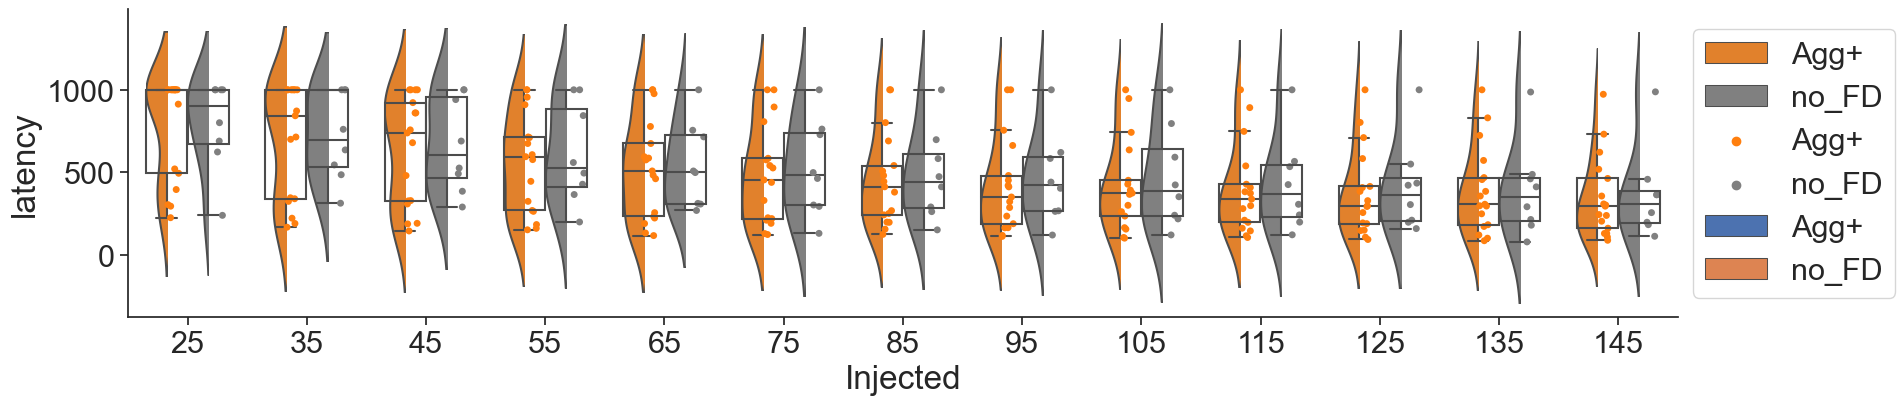

In [34]:
prop = 'latency'

fig = plt.subplots(figsize = [20,4])

palette = ['Tab:orange', 'gray']
ax = sns.violinplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', 
                    dodge = True, data = df,
                    palette=palette,width = 0.7,
                    scale="width", inner=None)

# ax = sns.lmplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', data = df)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

old_len_collections = len(ax.collections)
sns.stripplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
               dodge = True, data = df, palette=palette, ax=ax)

sns.boxplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
                data = df, saturation=1, showfliers=False,
            width=0.7, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)


for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([.08, 0]))
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)

sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [35]:
model = smf.ols('latency ~ C(Injected) * C(Behaviour_6hFD)', data=df).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Injected),5.312220e+06,12.0,5.400609,2.648369e-08
C(Behaviour_6hFD),7.187719e+04,1.0,0.876878,3.498140e-01
C(Injected):C(Behaviour_6hFD),1.233019e+04,12.0,0.012535,1.000000e+00
Residual,2.450887e+07,299.0,NaN,NaN


In [36]:
df['combination'] = df.Injected.astype(str) + " / " + df.Behaviour_6hFD
m_comp = pairwise_tukeyhsd(endog=df['latency'], groups=df['combination'], alpha=0.05)
m_comp._results_table

group1,group2,meandiff,p-adj,lower,upper,reject
105 / Agg+,105 / no_FD,53.6741,1.0,-402.1284,509.4766,False
105 / Agg+,115 / Agg+,-24.5592,1.0,-389.2012,340.0828,False
105 / Agg+,115 / no_FD,10.2366,1.0,-445.5659,466.0391,False
105 / Agg+,125 / Agg+,-40.0064,1.0,-404.6483,324.6356,False
105 / Agg+,125 / no_FD,-4.3258,1.0,-460.1283,451.4766,False
105 / Agg+,135 / Agg+,-25.7058,1.0,-390.3478,338.9361,False
105 / Agg+,135 / no_FD,-25.2135,1.0,-481.016,430.5889,False
105 / Agg+,145 / Agg+,-68.4944,1.0,-433.1364,296.1476,False
105 / Agg+,145 / no_FD,-48.6384,1.0,-504.4409,407.1641,False
105 / Agg+,25 / Agg+,359.0997,0.0598,-5.5423,723.7417,False


# estrous cycle influence

I_zero         phasic  silent  tonic  All
estrous_stage                            
?                   1       1      2    4
D                   7       9     24   40
E                   3       6      7   16
M                   1       3      6   10
P                   1       3      7   11
no VS               1       2      9   12
not taken           1       2      1    4
All                15      26     56   97
0.9215991728130059
I_zero         phasic  silent  tonic  All
estrous_stage                            
D                   2       5      3   10
E                   2       1      0    3
M                   0       6      3    9
P                   0       3      2    5
All                 4      15      8   27
0.15470260638548464


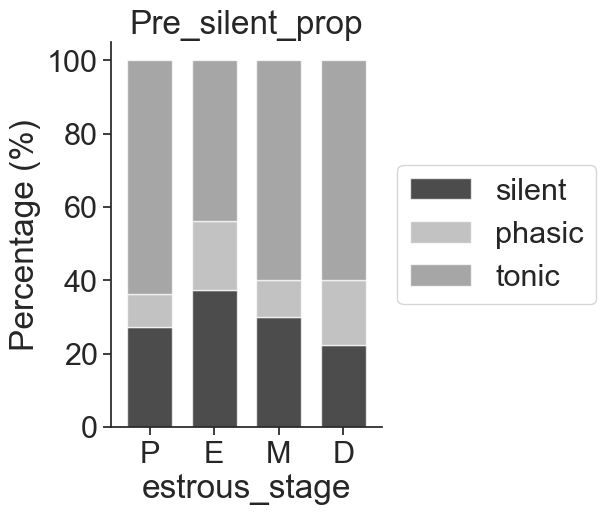

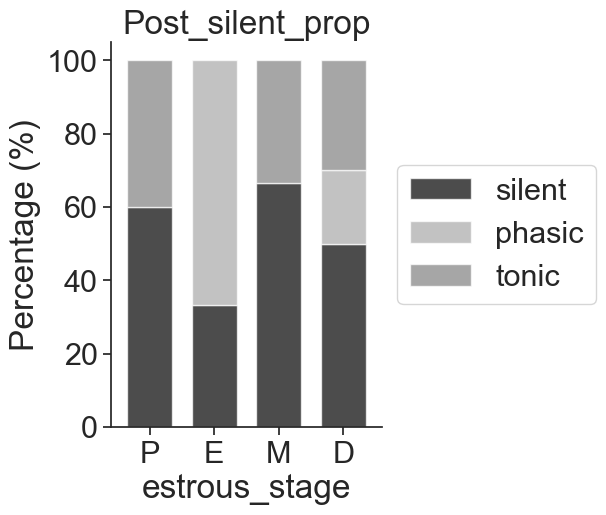

In [18]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]

    silent_prop.plot(x = 'estrous_stage', 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3.5,5), alpha = 0.7, width = 0.7)
    
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

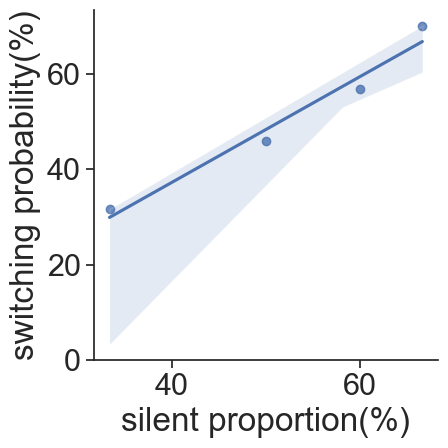

In [19]:
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

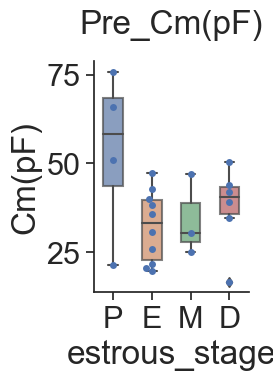

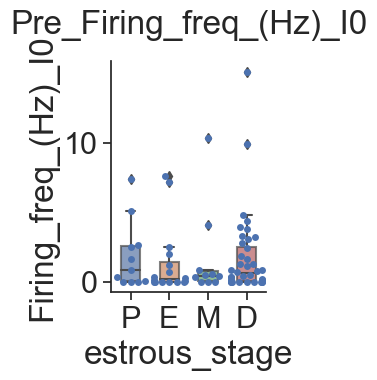

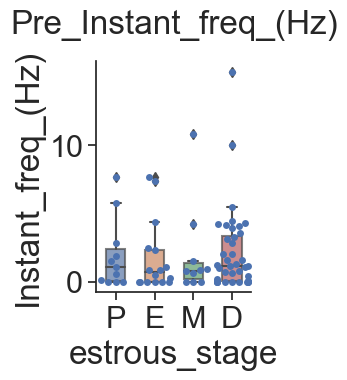

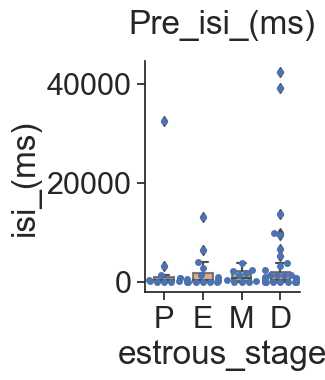

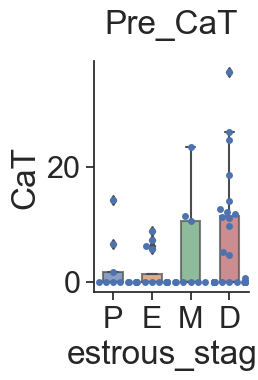

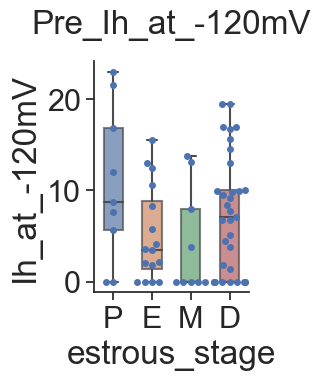

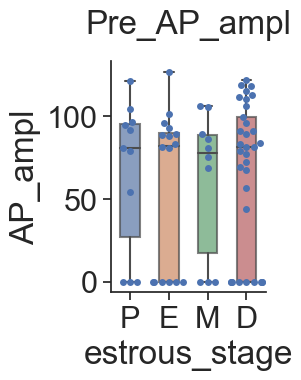

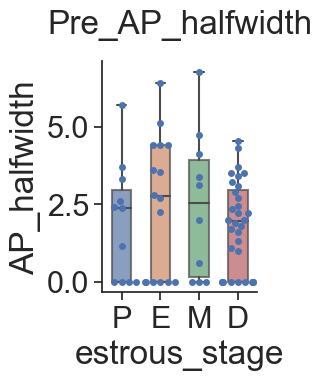

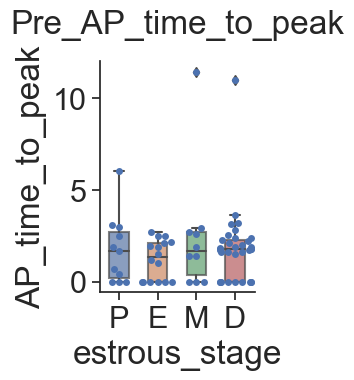

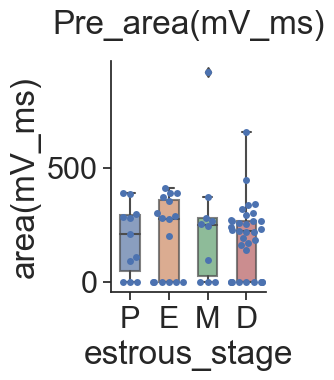

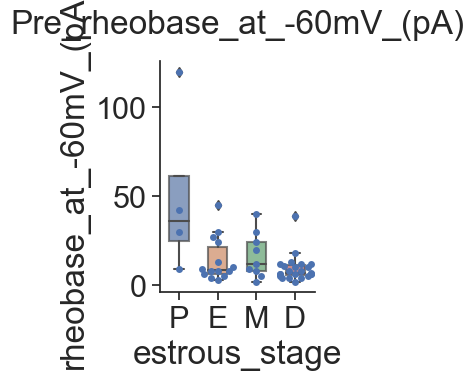

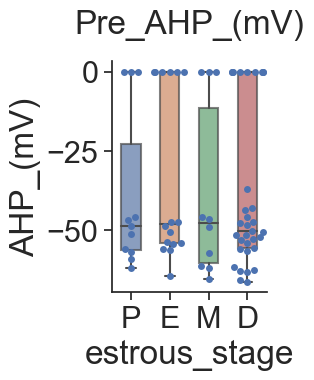

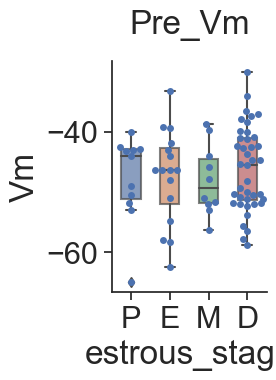

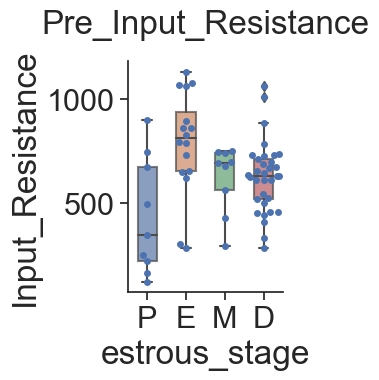

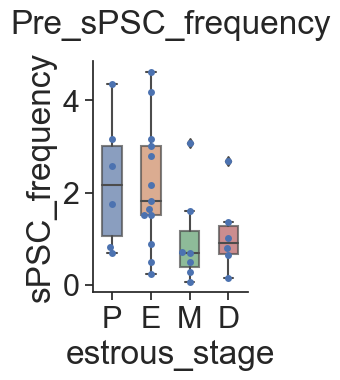

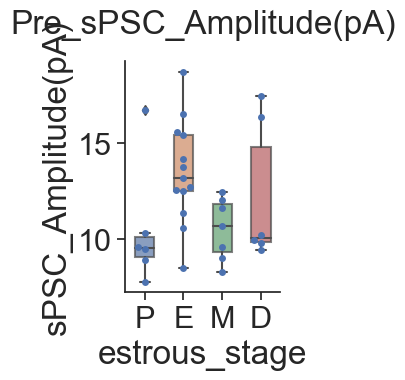

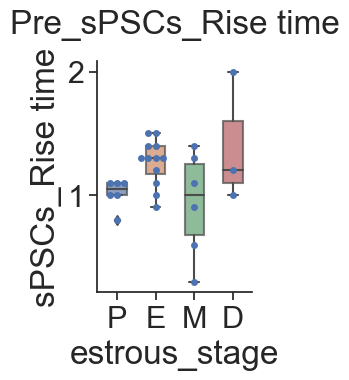

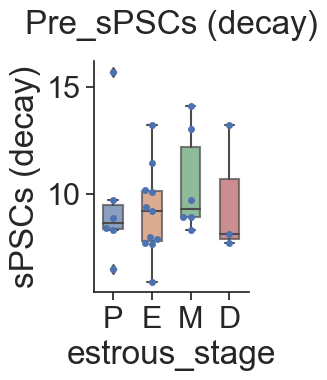

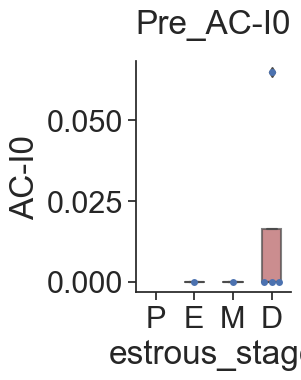

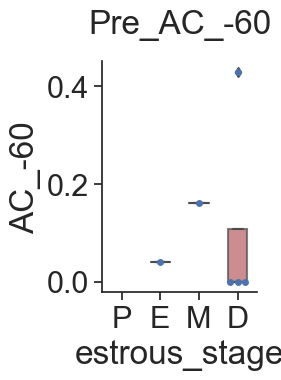

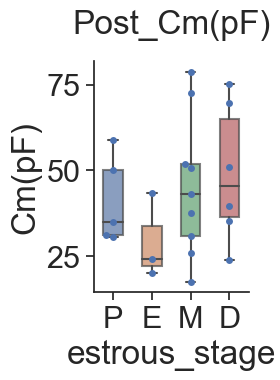

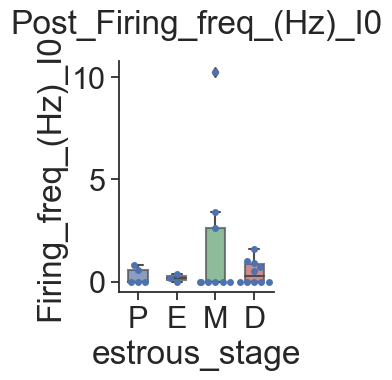

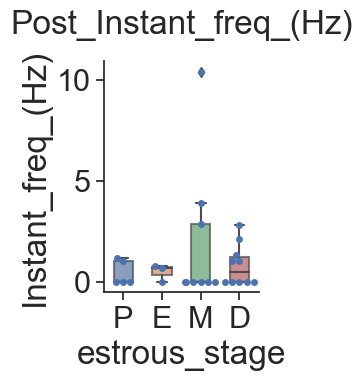

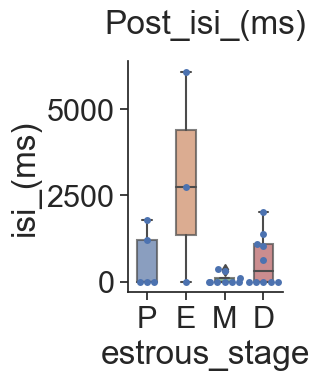

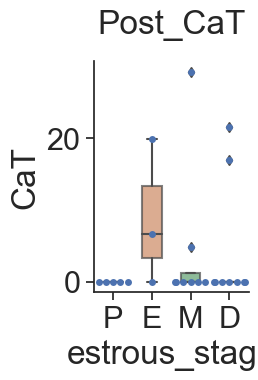

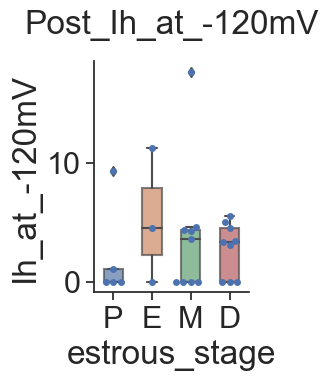

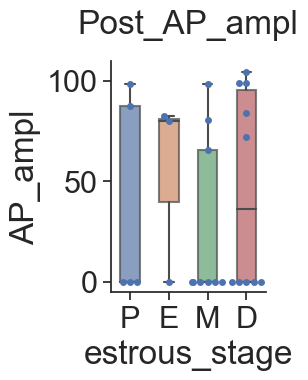

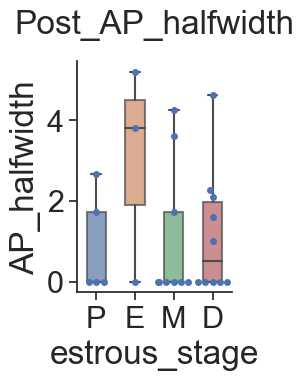

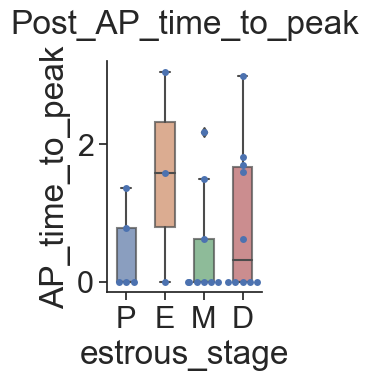

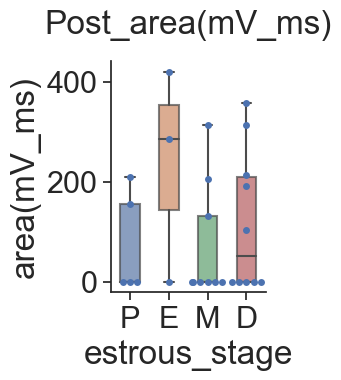

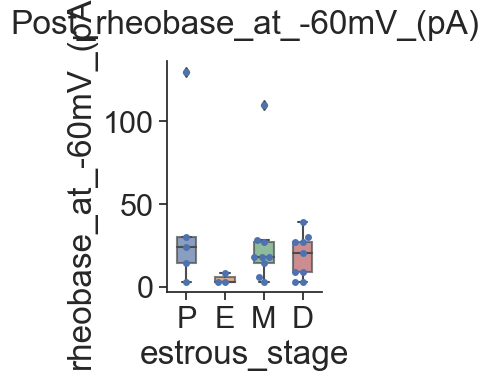

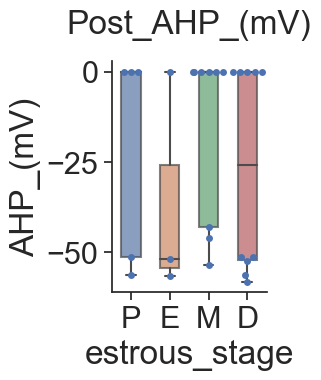

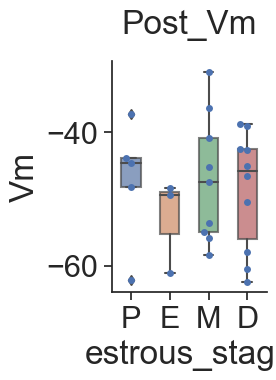

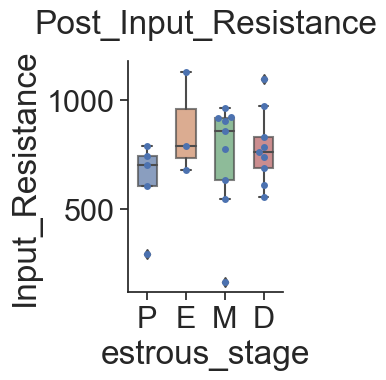

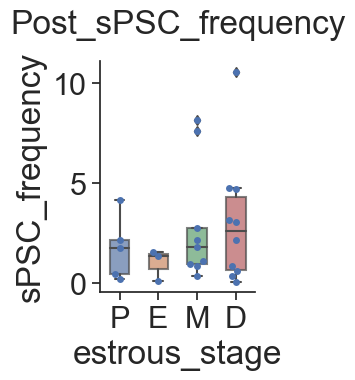

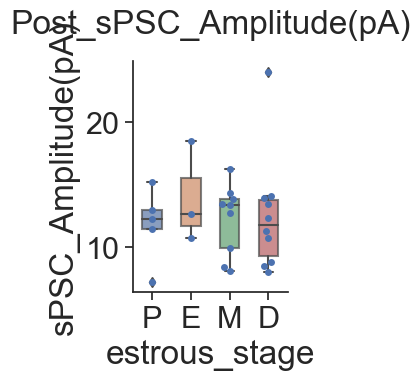

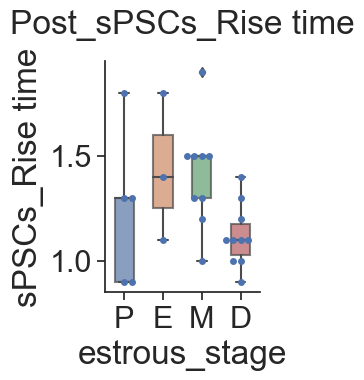

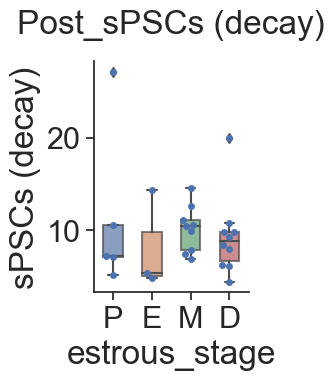

KeyError: 'y'

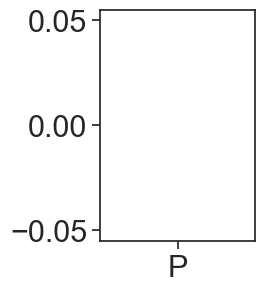

In [20]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for state in ['Pre', 'Post']:
    for column in ls:
        state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        
        fig,ax = plt.subplots(figsize = (2,3))
        sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 1)
        sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5)
        sns.despine()
        plt.title(f'{state}_{column}', pad = 20)
        
        plt.show()

# npy administration

In [21]:
npy_df = pd.read_csv('npy_administration.csv')
npy_df = npy_df.melt(id_vars=['cell_id'], value_vars=['Vm control', 'Vm NPY'], var_name='condition', value_name='Vm')

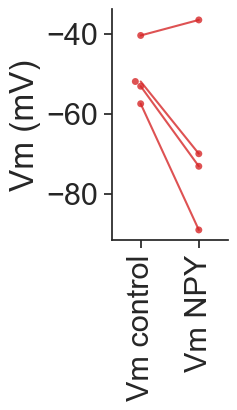

In [22]:
plt.subplots(figsize = (1.5,3))
sns.lineplot(x = 'condition', y = 'Vm', hue = 'cell_id',data = npy_df, palette = ['Tab:red'], alpha = 0.8)
sns.swarmplot(x = 'condition', y = 'Vm', hue = 'cell_id',data = npy_df, palette = ['Tab:red'], alpha = 0.8)
ax = plt.gca()
ax.get_legend().remove()
sns.despine()
plt.xticks(rotation = 90)
plt.xlabel('')
plt.ylabel('Vm (mV)')
plt.savefig('output_figures/npy_Vm.png', dpi = 300, bbox_inches = 'tight')